<a href="https://colab.research.google.com/github/europecodingschool/ECS---VB---YZ---08.26/blob/main/VB_YZ_Ders_12_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

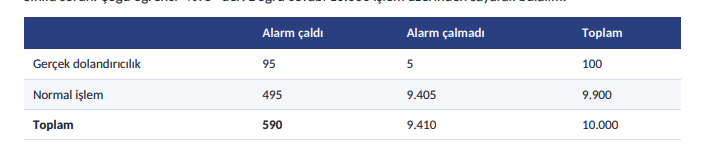

Örnek case için Bayes Teorem.
**kalın metin**
Bir bankanın dolandırıcılık alarm sistemi var.
İşlemlerin sadece %1 i gerçekten dolandırıcılık.
Sistem gerçek dolandırıcıların %95 ini yakalıyormuş. (alarm veriyor)
Normal işlemlerin de %5 inde yanlış alarm veriyor.
Bir işlem için alarm çaldı %kaç dolandırıcılık olma ihtimali var?

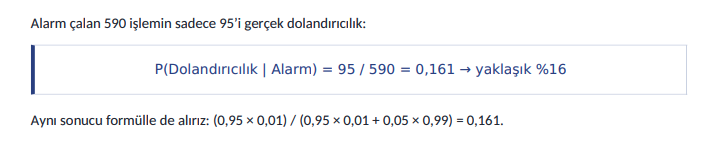

Naive Bayes Algoritması - Geçmişteki verilerin gerçekleşme sıklığına bakarak, gelecekteki verilerin hangi sınıfa ait olacağını
hesaplar.

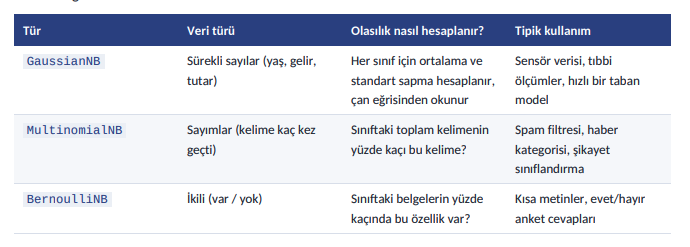

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("/content/Ders_11_kanser_veriseti_detayli.csv")

In [6]:
df.head()

,Tumor_Boyutu,Hucre_Yogunlugu,Hasta_Yasi,Aile_Gecmisi,Sigara_Kullanimi,Kanser_Mi
0,5.29,6.2,35,0,0,1
1,6.11,8.4,53,0,1,1
2,2.76,3.3,51,1,0,0
3,3.87,8.5,50,0,0,1
4,4.53,5.4,60,0,0,1


In [8]:
df.describe()

,Tumor_Boyutu,Hucre_Yogunlugu,Hasta_Yasi,Aile_Gecmisi,Sigara_Kullanimi,Kanser_Mi
count,400.000000,400.00000,400.000000,400.000000,400.000000,400.00000
mean,3.412800,5.15950,52.382500,0.192500,0.392500,0.50250
std,2.018861,2.39647,12.919888,0.394757,0.488919,0.50062
min,0.100000,1.00000,18.000000,0.000000,0.000000,0.00000
25%,1.807500,3.10000,43.000000,0.000000,0.000000,0.00000
50%,2.925000,5.00000,52.000000,0.000000,0.000000,1.00000
75%,4.800000,7.22500,62.000000,0.000000,1.000000,1.00000
max,9.910000,10.00000,83.000000,1.000000,1.000000,1.00000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Tumor_Boyutu      400 non-null    float64
 1   Hucre_Yogunlugu   400 non-null    float64
 2   Hasta_Yasi        400 non-null    int64  
 3   Aile_Gecmisi      400 non-null    int64  
 4   Sigara_Kullanimi  400 non-null    int64  
 5   Kanser_Mi         400 non-null    int64  
dtypes: float64(2), int64(4)
memory usage: 18.9 KB


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.naive_bayes import GaussianNB

In [14]:
#1. Veriyi Ayırma
X = df.drop("Kanser_Mi", axis=1)
y = df["Kanser_Mi"]

In [16]:
#2. Veriyi train ve test olarak ayırma.
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [18]:
#3. VERİ ÖLÇEKLENDİRME - ölçeklendirmesekte olurdu ama zararı olmaz.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
#4. MODEL EĞİTİMİ
model = GaussianNB()
model.fit(X_train_scaled,y_train)

GaussianNB()

In [22]:
#5. TAHMİNLEME
y_pred = model.predict(X_test_scaled)

In [24]:
#6. BAŞARI METRİKLERİ
accuracy_score(y_test,y_pred) # tahminlerimizin %kaçı doğru.

0.9625

In [26]:
precision_score(y_test,y_pred) # Model 'Bu kişi kanser dedğinde %95 oranında doğru. Haklı.

0.9444444444444444

In [28]:
recall_score(y_test,y_pred) # Gerçekten kanser olan hastaların %90.47 sini yakalayabilmişim.

0.9714285714285714

In [30]:
f1_score(y_test,y_pred) # kesinlik ve duyarlılığı iyi. Model dengeli.

0.9577464788732394

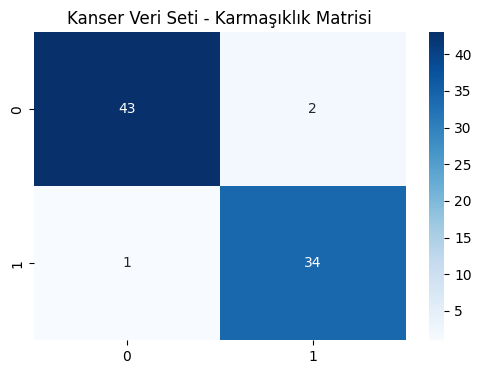

In [31]:
#karmaşıklık matrix ini seaborn kullanarak daha güzel ve anlaşılır halde çizmek.
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True, cmap='Blues', )
plt.title('Kanser Veri Seti - Karmaşıklık Matrisi')
plt.show()